In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=500

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
allrgs=load("allrgs.npy")

Text(0.5, 1.0, 'Wild Type')

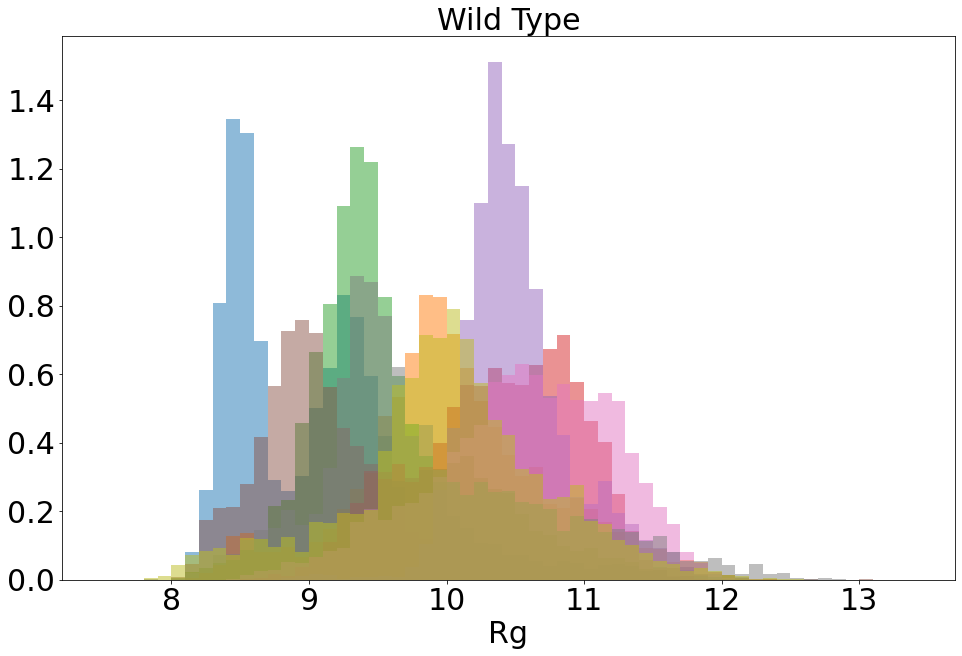

In [4]:
binrange = arange(7.5,13.5,0.1)
#WT

figure(figsize = (16,10))
for i in range(len(allrgs[1])):
    hist(allrgs[1][i][EQPOINT:],alpha = 0.5,bins = binrange,density = True)
    
xlabel("Rg",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
title("Wild Type",fontsize = 30)

Text(0.5, 1.0, 'R332P')

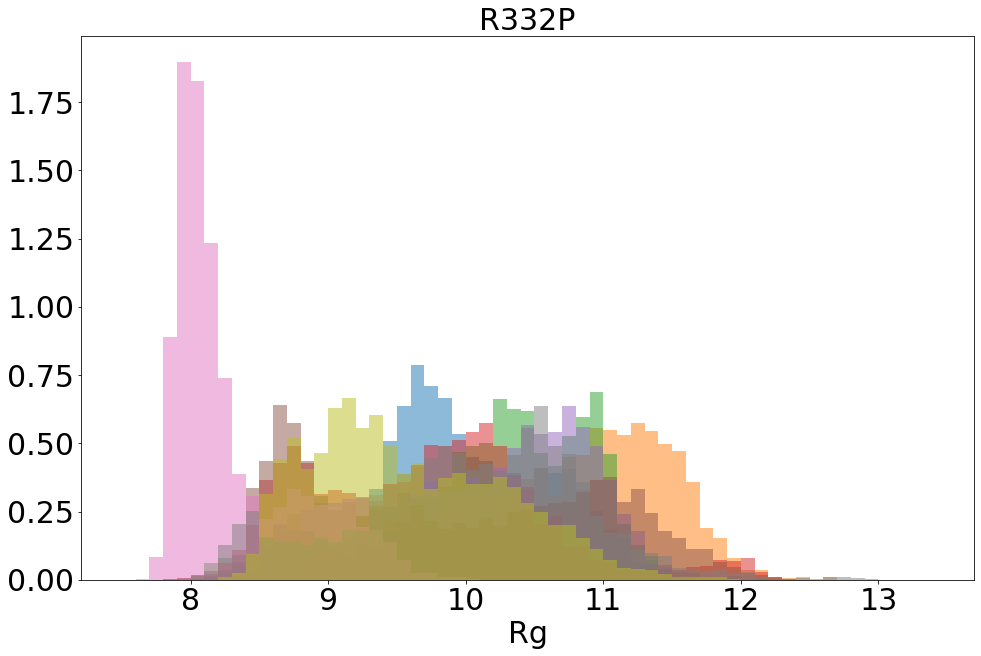

In [5]:
binrange = arange(7.5,13.5,0.1)
#r332p

figure(figsize = (16,10))
for i in range(len(allrgs[2])):
    hist(allrgs[2][i][EQPOINT:],alpha = 0.5,bins = binrange,density = True)
    
xlabel("Rg",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
title("R332P",fontsize = 30)

Text(0.5, 1.0, 'Rh')

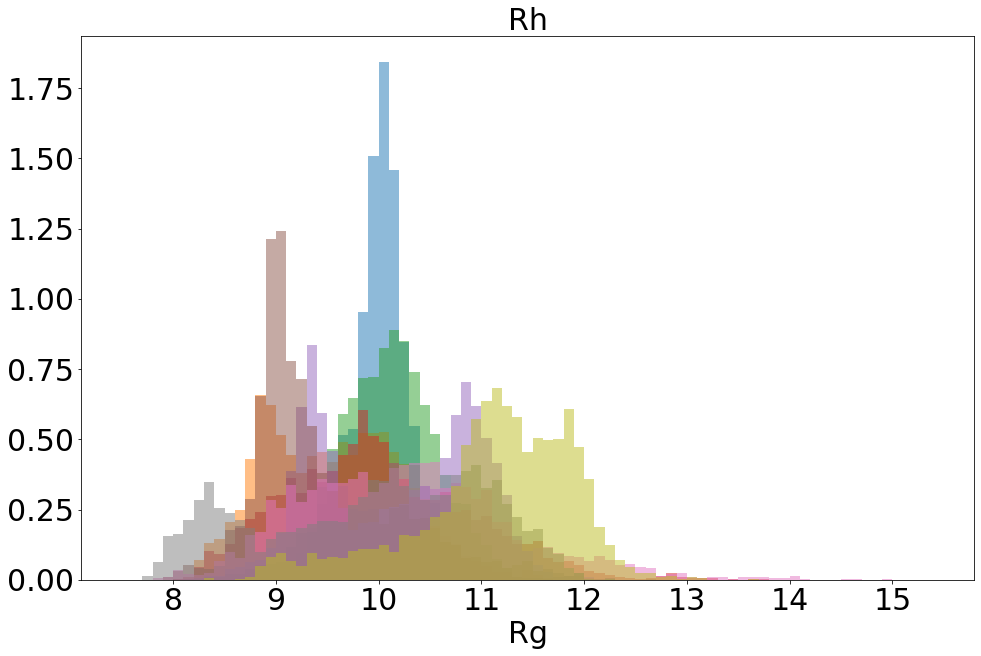

In [6]:
binrange = arange(7.5,15.5,0.1)
#r332p

figure(figsize = (16,10))
for i in range(len(allrgs[0])):
    hist(allrgs[0][i][EQPOINT:],alpha = 0.5,bins = binrange,density = True)
    
xlabel("Rg",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
title("Rh",fontsize = 30)

In [10]:
def getRMSD(datasets):
    """ Takes data set and returns mean and standard error for each one """
    rmsds=[]
    sterrs=[]
    allrmsds=[]
    
    for i in range(len(datasets)):
        sub_rmsds=[]
        for j in range(len(datasets[i])):
            
                
            R = MDAnalysis.analysis.rms.RMSD(datasets[i][j],datasets[i][0])
                
            R.run()
            sub_rmsds.append(R.rmsd.T[2])
        allrmsds.append(sub_rmsds)
        rmsds.append(mean(sub_rmsds,axis = 0))
        sterrs.append(scipy.stats.sem(sub_rmsds))
        
    return rmsds,sterrs, allrmsds

allrmsds=getRMSD(v1s)[2]



In [11]:
allrmsds[1][i].shape

(4001,)

Text(0.5, 1.0, 'Wild Type')

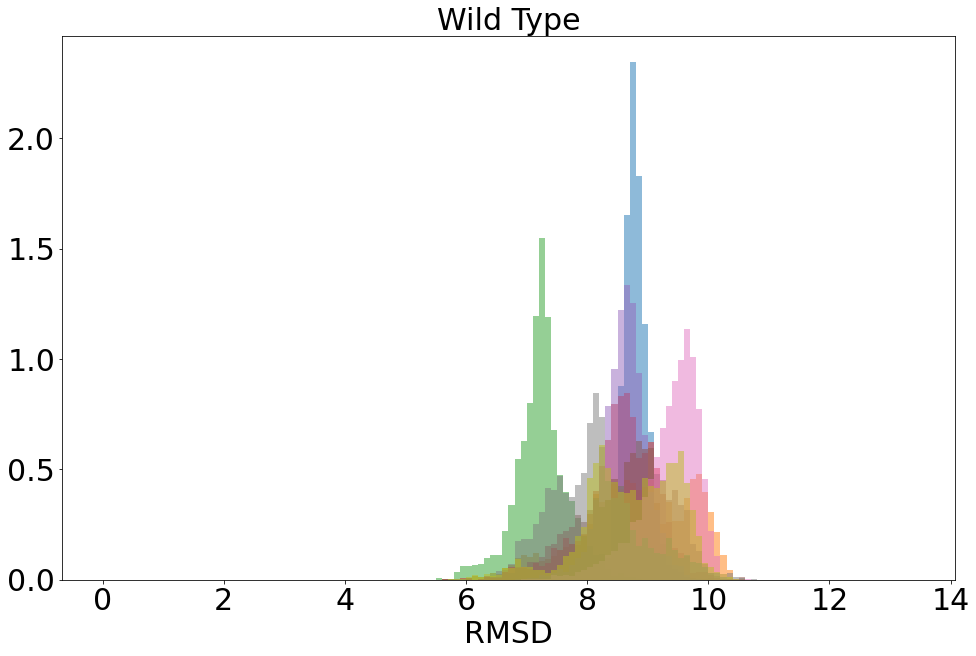

In [12]:
binrange = arange(0,13.5,0.1)
#WT

figure(figsize = (16,10))
for i in range(len(allrmsds[1])):
    hist(allrmsds[1][i][EQPOINT:],alpha = 0.5,bins = binrange,density = True)
    
xlabel("RMSD",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
title("Wild Type",fontsize = 30)

Text(0.5, 1.0, 'R332P')

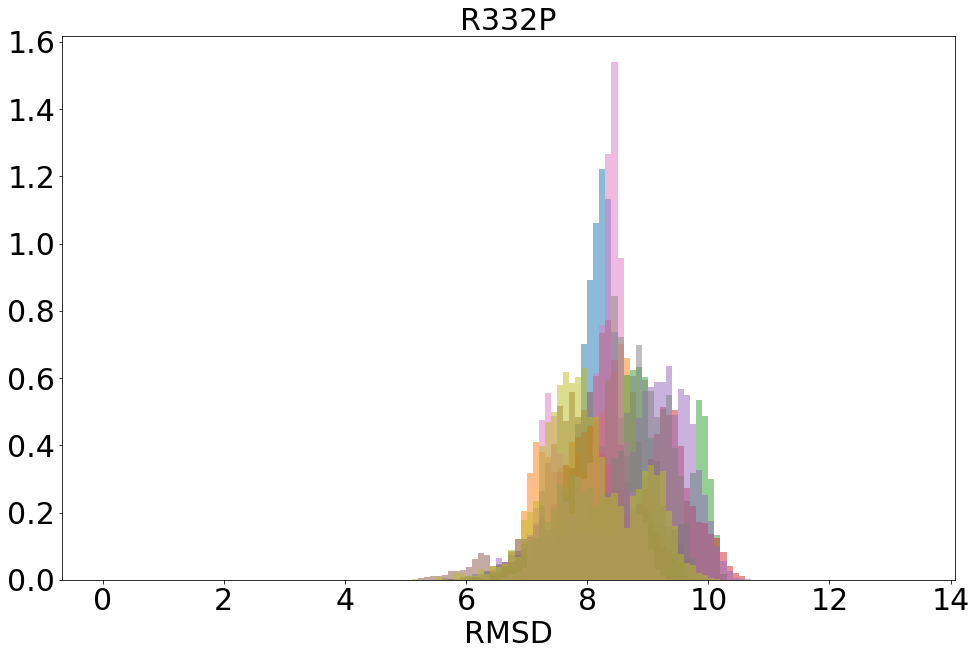

In [13]:
binrange = arange(0,13.5,0.1)
#WT

figure(figsize = (16,10))
for i in range(len(allrmsds[2])):
    hist(allrmsds[2][i][EQPOINT:],alpha = 0.5,bins = binrange,density = True)
    
xlabel("RMSD",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
title("R332P",fontsize = 30)

Text(0.5, 1.0, 'Rh')

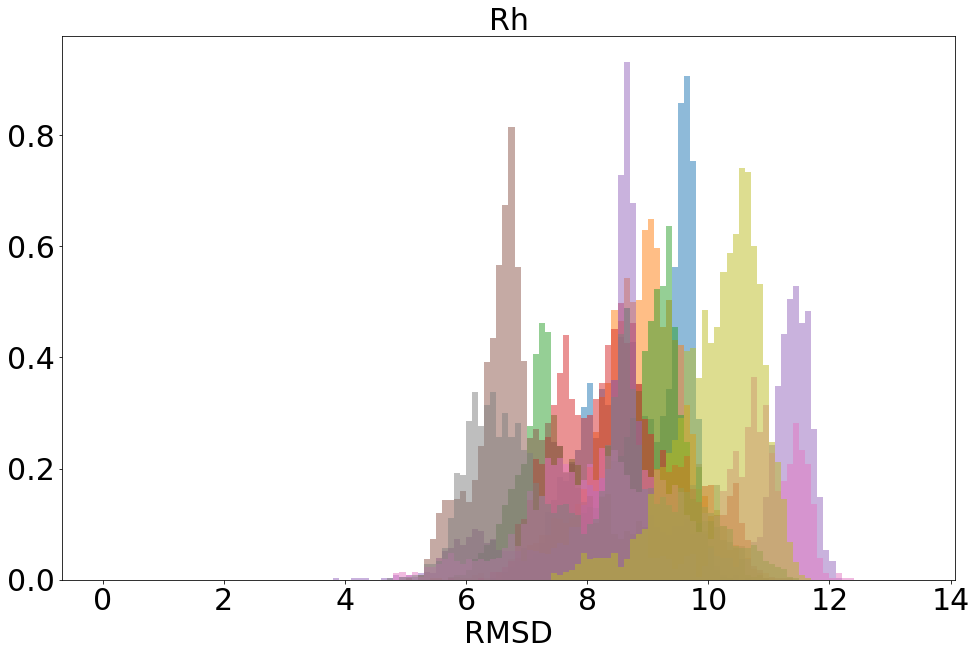

In [14]:
binrange = arange(0,13.5,0.1)
#WT

figure(figsize = (16,10))
for i in range(len(allrmsds[0])):
    hist(allrmsds[0][i][EQPOINT:],alpha = 0.5,bins = binrange,density = True)
    
xlabel("RMSD",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
title("Rh",fontsize = 30)

In [26]:
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists

dists = getPairwiseDists(systems,v1s,v1strings,stride = 1,EQPOINT=EQPOINT)

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


Text(0.5, 0, 'PC1')

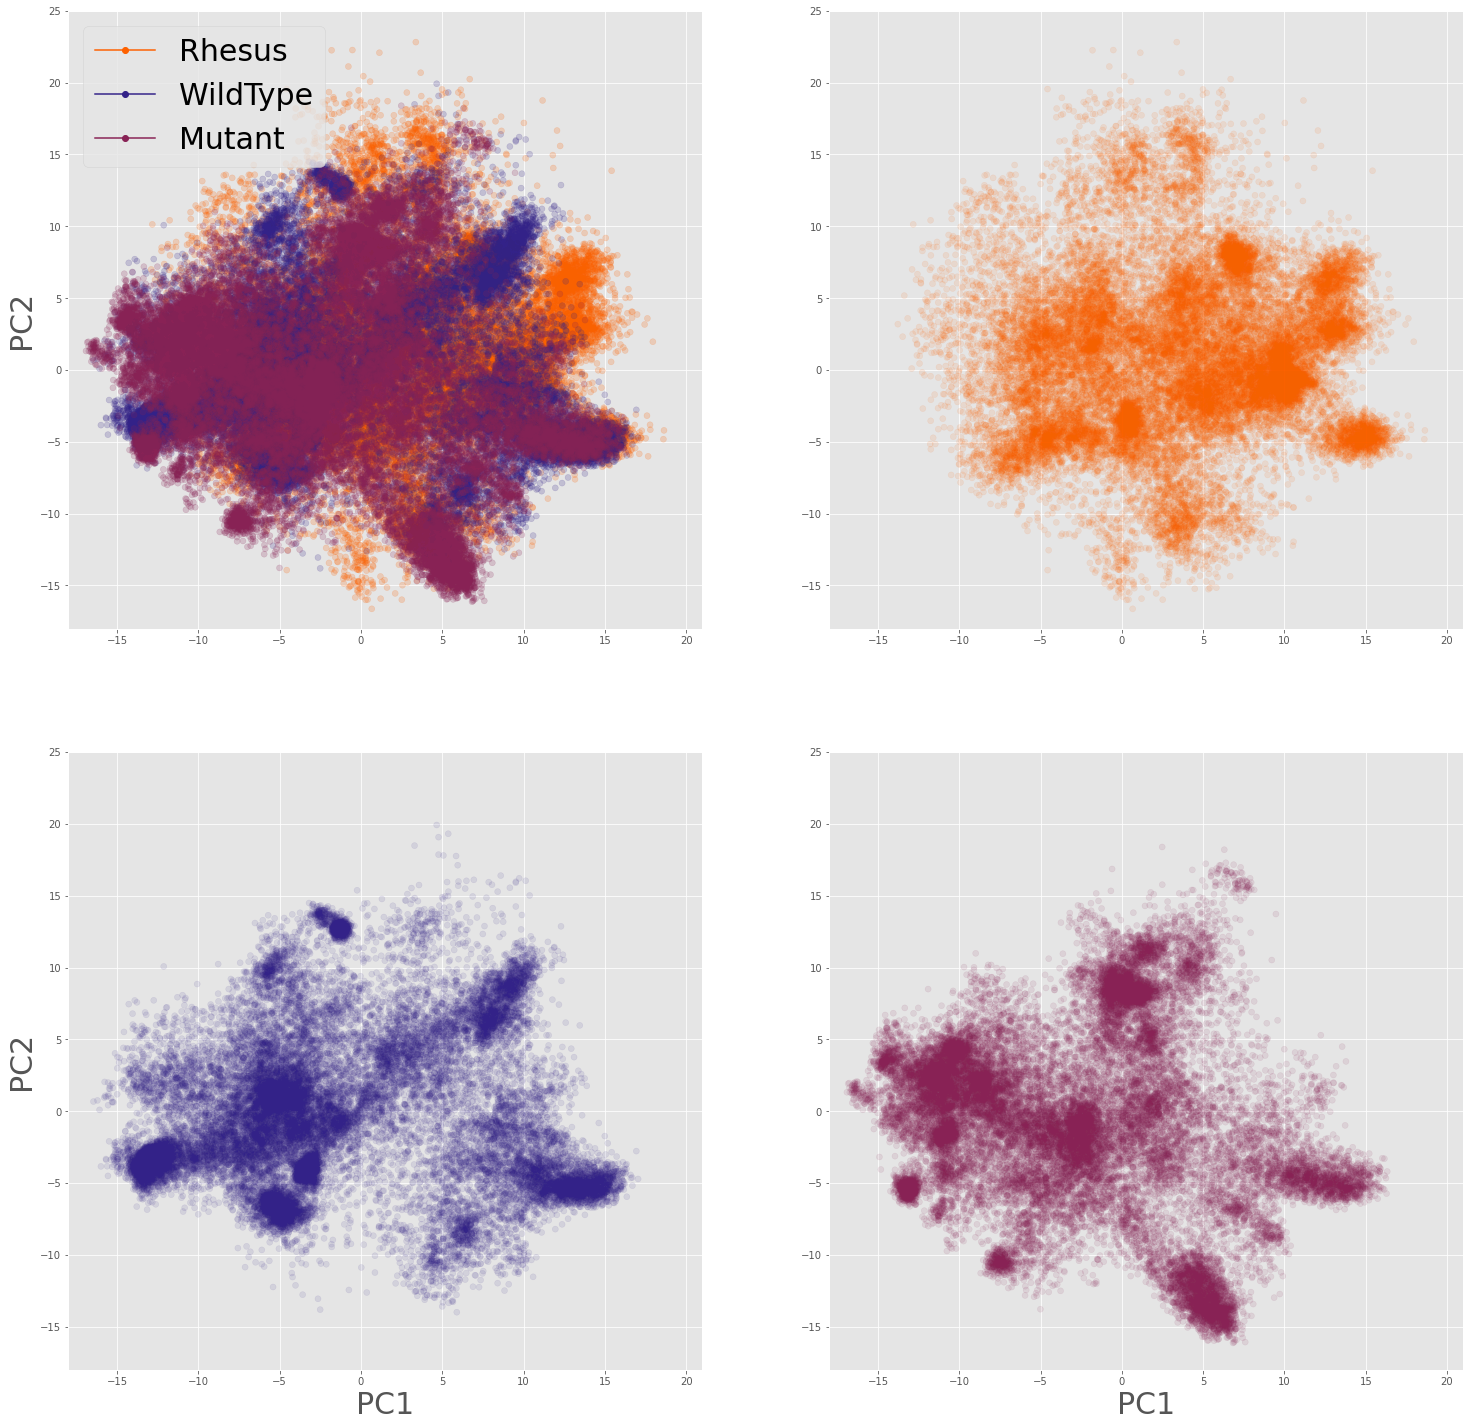

In [27]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
ylim(-18,25)
xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],color = pca_colours[:int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)

subplot(2,2,3)
scatter(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],color = pca_colours[int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],color = pca_colours[2*int(len(pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)


C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 49.99999999999995, 'PC1')

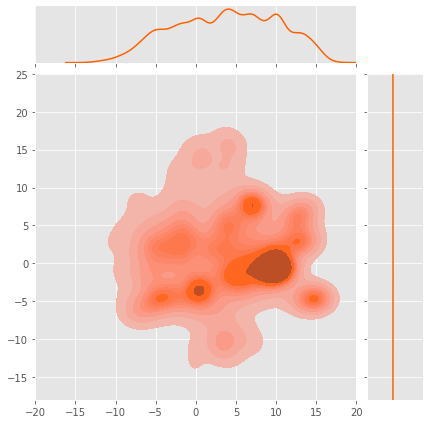

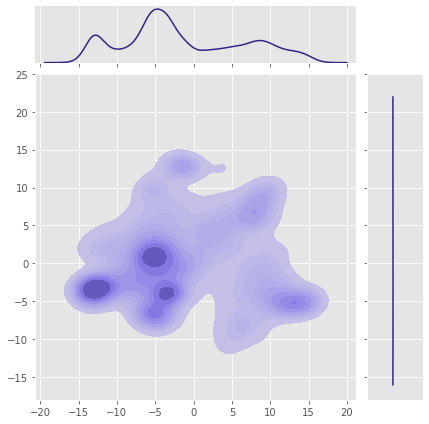

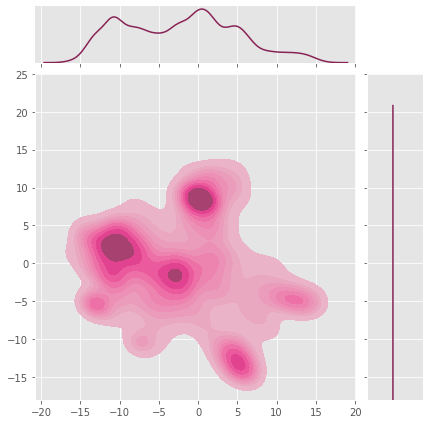

In [29]:
sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0],xlim = (-20,20))

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)

sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)

In [7]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

Text(0.5, 1.0, 'Rh')

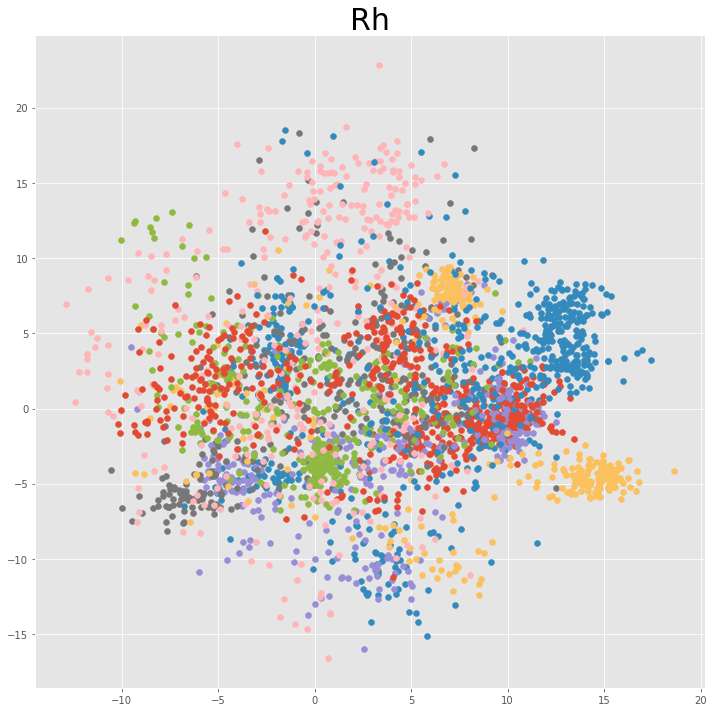

In [8]:
figure(figsize = (12,12))
for i in range(len(transformed_dists[0])):
    scatter(transformed_dists[0][i].T[0],transformed_dists[0][i].T[1])
title("Rh", fontsize = 30)

Text(0.5, 1.0, 'WT')

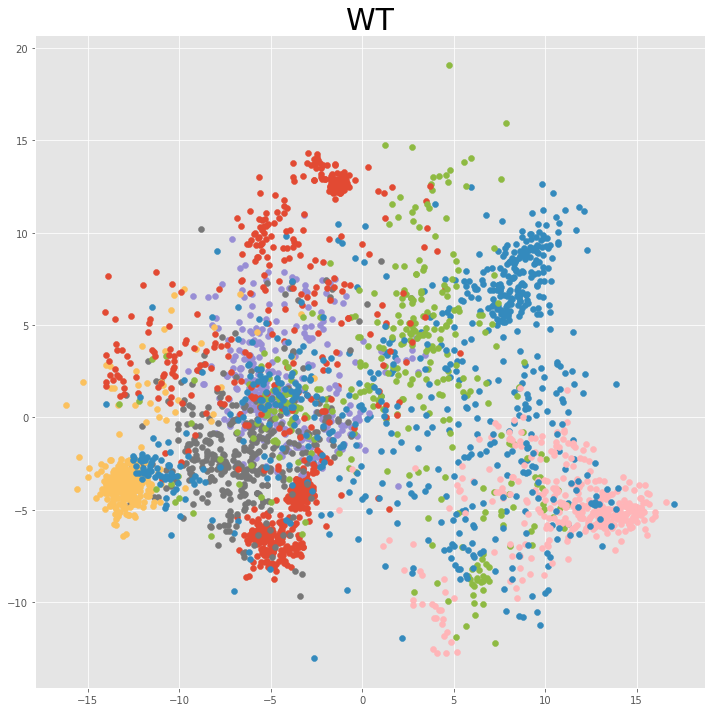

In [9]:
figure(figsize = (12,12))
for i in range(len(transformed_dists[1])):
    scatter(transformed_dists[1][i].T[0],transformed_dists[1][i].T[1])
title("WT", fontsize = 30)

Text(0.5, 1.0, 'R332P')

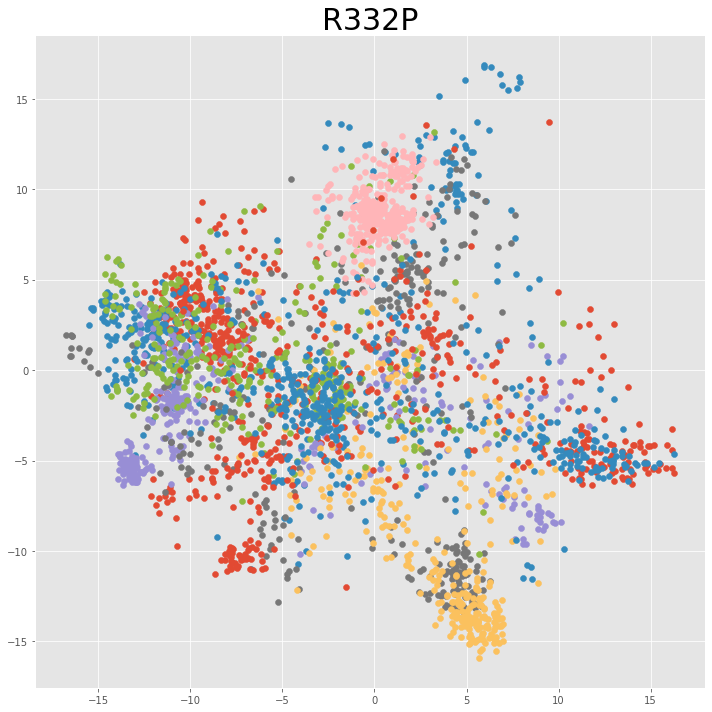

In [10]:
figure(figsize = (12,12))
for i in range(len(transformed_dists[2])):
    scatter(transformed_dists[2][i].T[0],transformed_dists[2][i].T[1])
title("R332P", fontsize = 30)

In [114]:
# System Individuall


C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


Text(0.5, 1.0, 'WT')

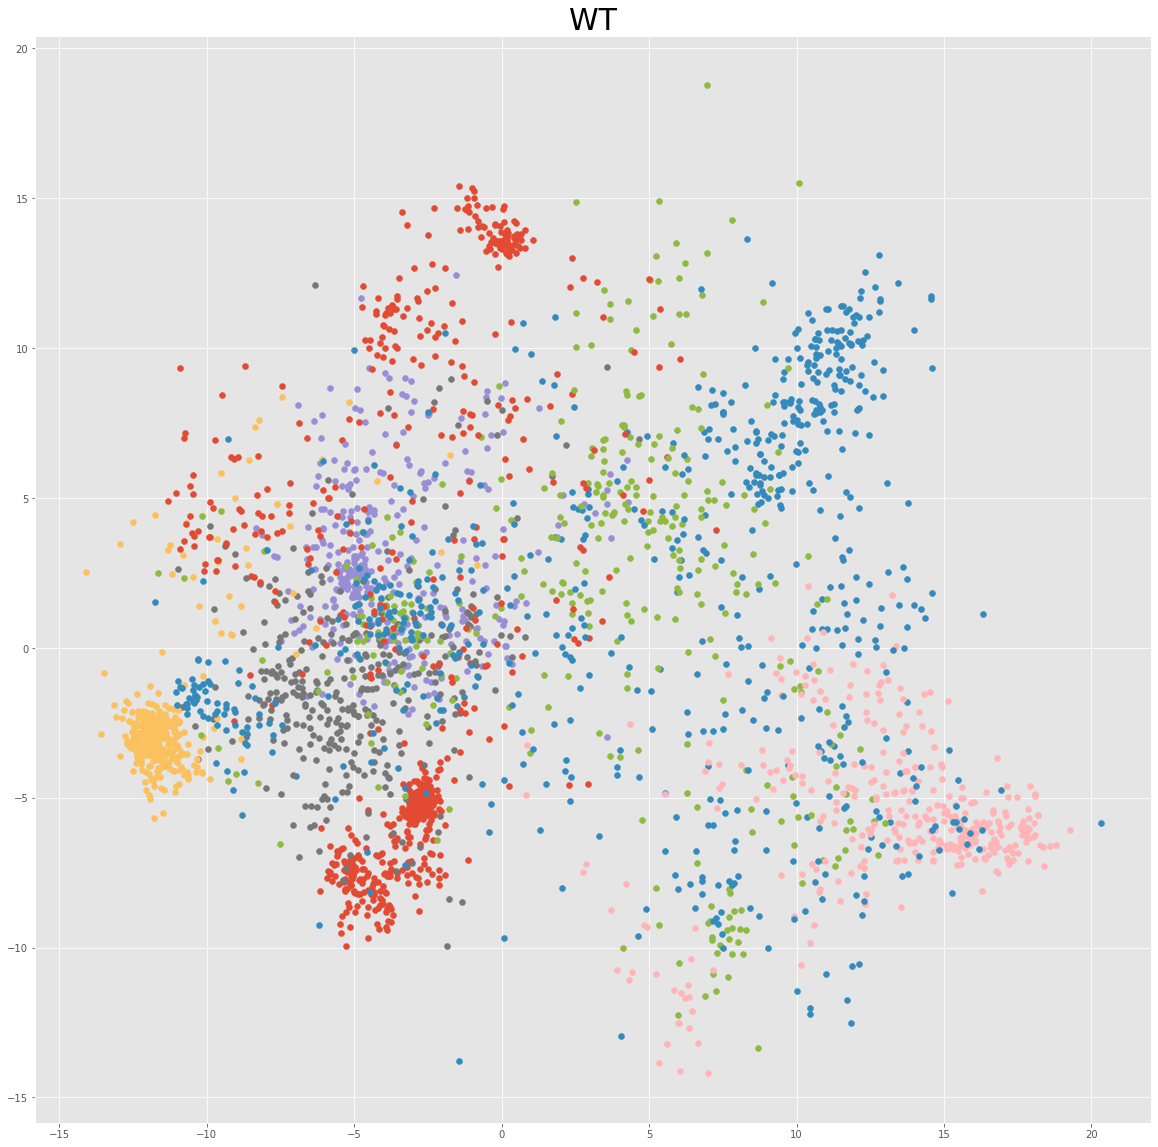

In [11]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists

dists = getPairwiseDists([systems[1]],[v1s[1]],[v1strings[1]],stride = 10,EQPOINT=EQPOINT)
shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i+1])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)


figure(figsize = (20,20))
for i in range(len(transformed_dists[0])):
    scatter(transformed_dists[0][i].T[0],transformed_dists[0][i].T[1])
title("WT", fontsize = 30)


C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


Text(0.5, 1.0, 'R332P')

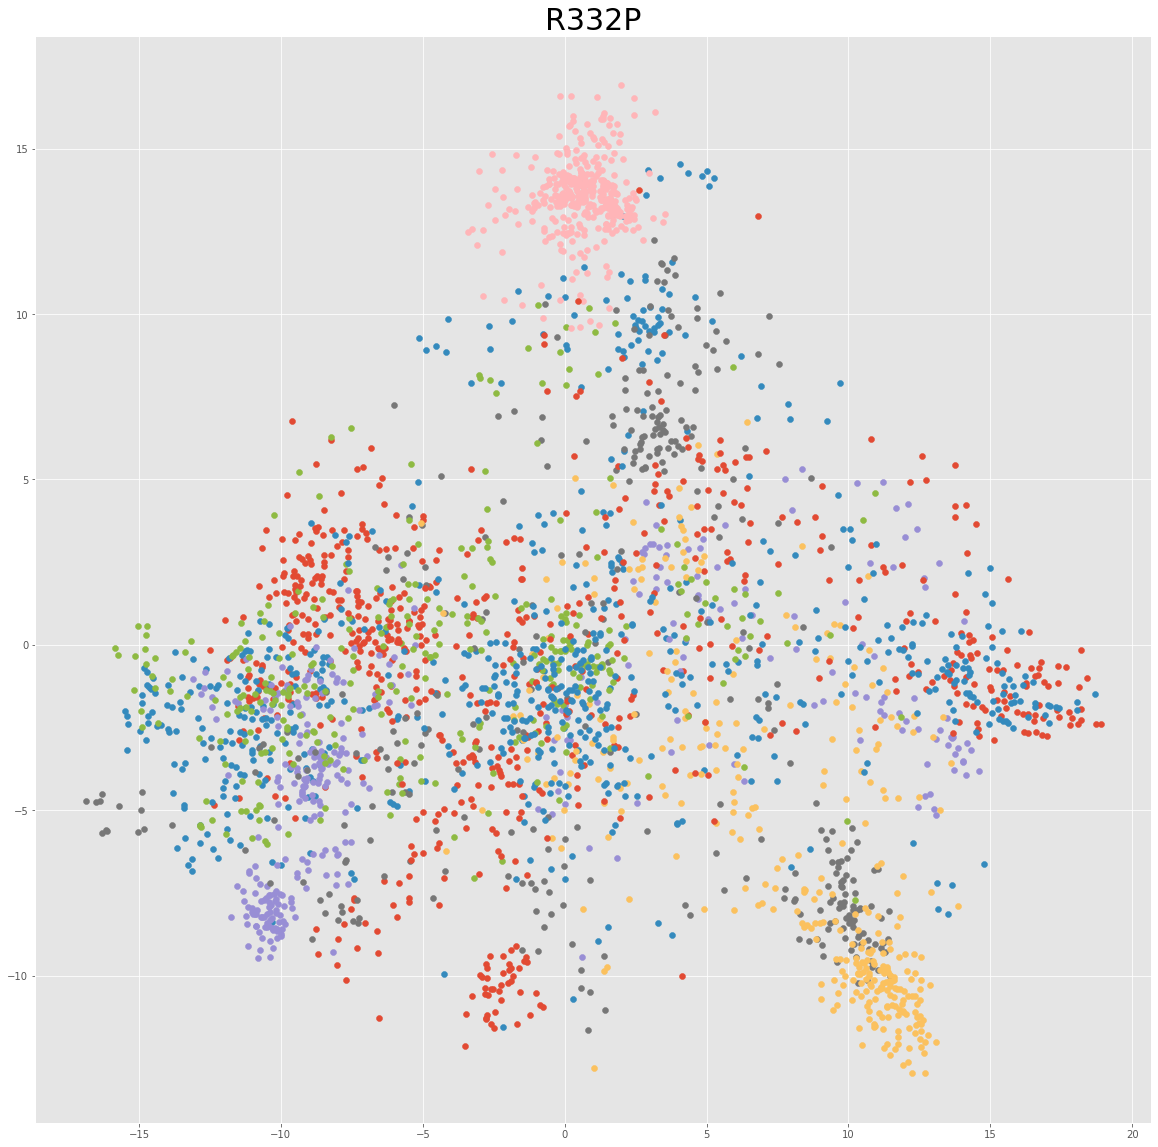

In [12]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists

dists = getPairwiseDists([systems[2]],[v1s[2]],[v1strings[2]],stride = 10,EQPOINT=EQPOINT)
shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i+1])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

figure(figsize = (20,20))
for i in range(len(transformed_dists[0])):
    scatter(transformed_dists[0][i].T[0],transformed_dists[0][i].T[1])
title("R332P", fontsize = 30)


C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


Text(0.5, 1.0, 'Rh')

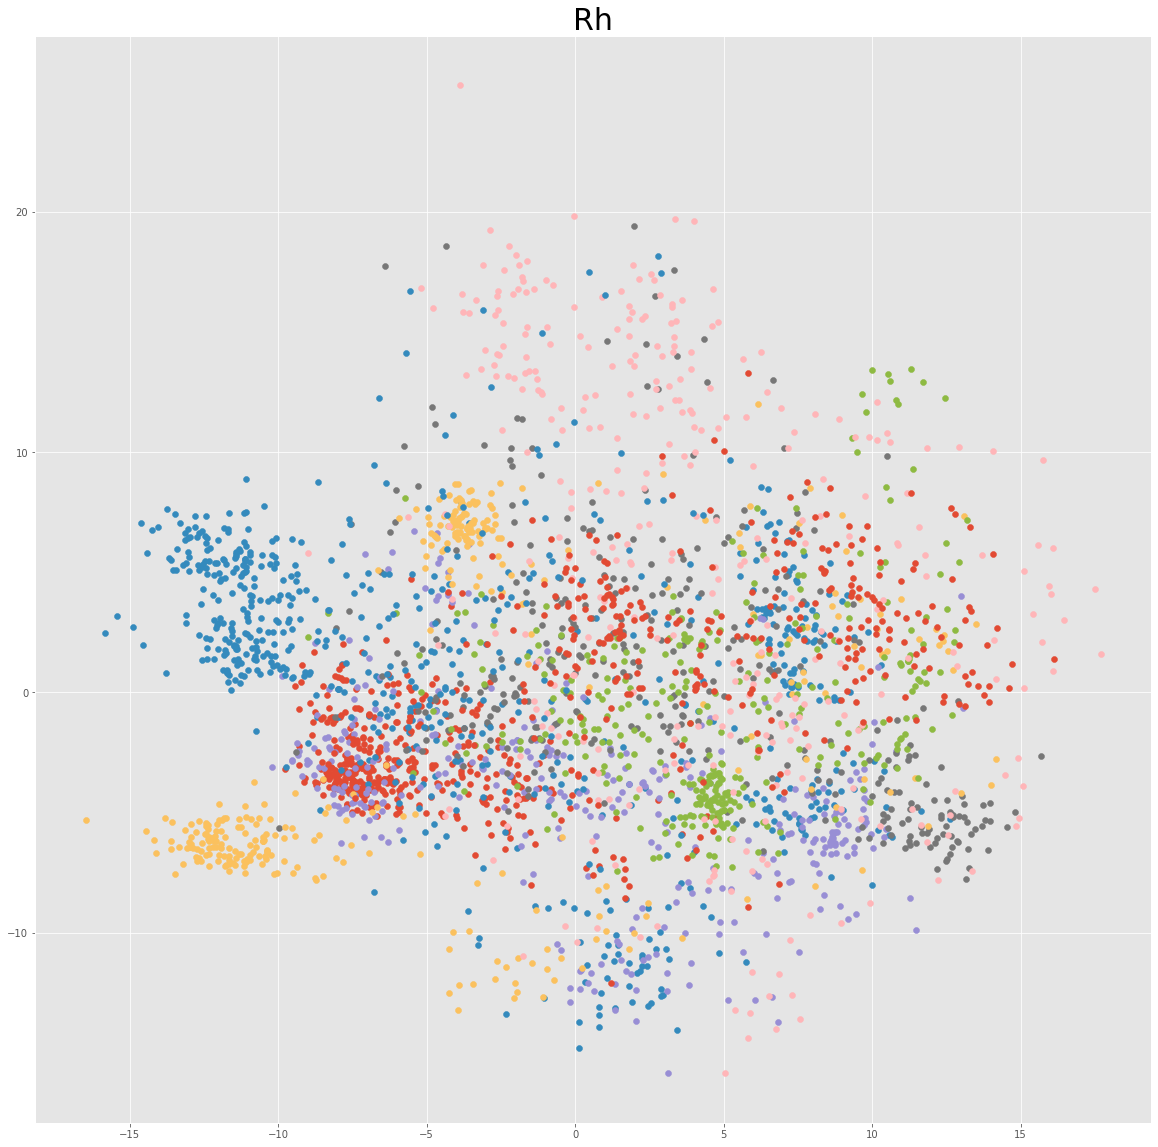

In [13]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists

dists = getPairwiseDists([systems[0]],[v1s[0]],[v1strings[0]],stride = 10,EQPOINT=EQPOINT)
shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i+1])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

figure(figsize = (20,20))
for i in range(len(transformed_dists[0])):
    scatter(transformed_dists[0][i].T[0],transformed_dists[0][i].T[1])
title("Rh", fontsize = 30)


In [14]:
#UMAP

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


<Figure size 1440x1440 with 0 Axes>

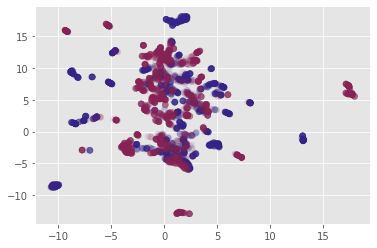

<Figure size 1440x1440 with 0 Axes>

In [16]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists

dists = getPairwiseDists(systems[1:],v1s[1:],v1strings[1:],stride = 10,EQPOINT=EQPOINT)
shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i+1])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)



#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_

fit = umap.UMAP()
u = fit.fit_transform(shaped_dists)

plt.scatter(u[:,0], u[:,1], c=pca_colours,alpha = 0.1)

figure(figsize = (20,20))
#for i in range(len(transformed_dists[0])):
#    scatter(transformed_dists[0][i].T[0],transformed_dists[0][i].T[1])
#title("WT", fontsize = 30)
#



C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(vals), dtype=np.bool)


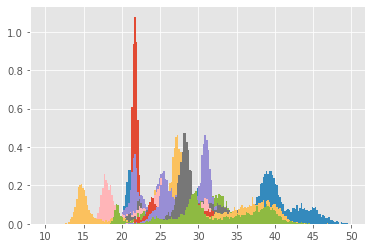

<Figure size 1152x864 with 0 Axes>

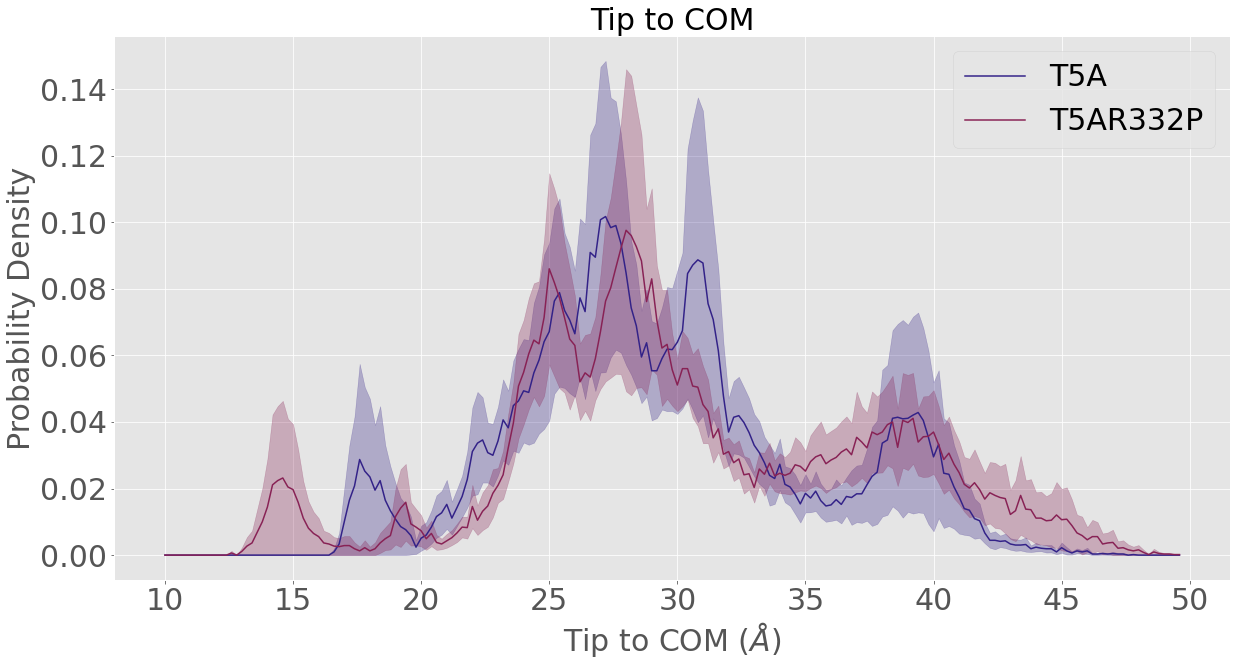

In [22]:

all_tip_to_com_dists=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        tu = systems[i][j]
        tipres = tu.select_atoms("name CA and resid 334")
        protein = tu.select_atoms("protein and not resid 324:345")
        
        tip_to_com_dists=[]
        for t in range(EQPOINT,len(tu.trajectory)):
            tu.trajectory[t]
            tip_to_com=tipres.atoms.positions[0] - protein.center_of_geometry()
            tip_to_com_dist = sqrt(dot(tip_to_com,tip_to_com))
            tip_to_com_dists.append(tip_to_com_dist)
            
        sub.append(tip_to_com_dists)
    all_tip_to_com_dists.append(sub)

    
binrange = arange(10,50,0.2)

all_tip_to_com_dists_hists=[]

for i in range(len(all_tip_to_com_dists)):
    sub=[]
    for j in range(len(all_tip_to_com_dists[i])):
        a=hist(all_tip_to_com_dists[i][j],bins = binrange,density = True)
        sub.append(a[0])
    all_tip_to_com_dists_hists.append(sub)
    
    
figure(figsize = (16,12))
avg_all_tip_to_com_dists_hists=[]
sem_all_tip_to_com_dists_hists=[]
for i in range(len(all_tip_to_com_dists_hists)):
    avg_all_tip_to_com_dists_hists.append(mean(all_tip_to_com_dists_hists[i],axis = 0))
    sem_all_tip_to_com_dists_hists.append(scipy.stats.sem(all_tip_to_com_dists_hists[i],axis = 0))
    

    


figure(figsize = (20,10))
#plot(binrange[:-1],avg_all_tip_to_com_dists_hists[0],color = colourScheme[0],label = system_names[0])
plot(binrange[:-1],avg_all_tip_to_com_dists_hists[1],color = colourScheme[1],label = system_names[1])
plot(binrange[:-1],avg_all_tip_to_com_dists_hists[2],color = colourScheme[2],label = system_names[2])


#fill_between(binrange[:-1], avg_all_tip_to_com_dists_hists[0] - sem_all_tip_to_com_dists_hists[0],avg_all_tip_to_com_dists_hists[0] + sem_all_tip_to_com_dists_hists[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], avg_all_tip_to_com_dists_hists[1] - sem_all_tip_to_com_dists_hists[1],avg_all_tip_to_com_dists_hists[1] + sem_all_tip_to_com_dists_hists[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], avg_all_tip_to_com_dists_hists[2] - sem_all_tip_to_com_dists_hists[2],avg_all_tip_to_com_dists_hists[2] + sem_all_tip_to_com_dists_hists[2],color = colourScheme[2],alpha = 0.3)


xlabel("Tip to COM ($\AA$)",fontsize = 30)
ylabel("Probability Density",fontsize = 30)
title("Tip to COM",fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)

legend(fontsize = 30)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(vals), dtype=np.bool)


C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:778: RuntimeWarning: invalid value encountered in double_scalars
  self._x1 = self._x0 + self._width
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:781: RuntimeWarning: invalid value encountered in double_scalars
  self._y1 = self._y0 + self._height


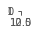

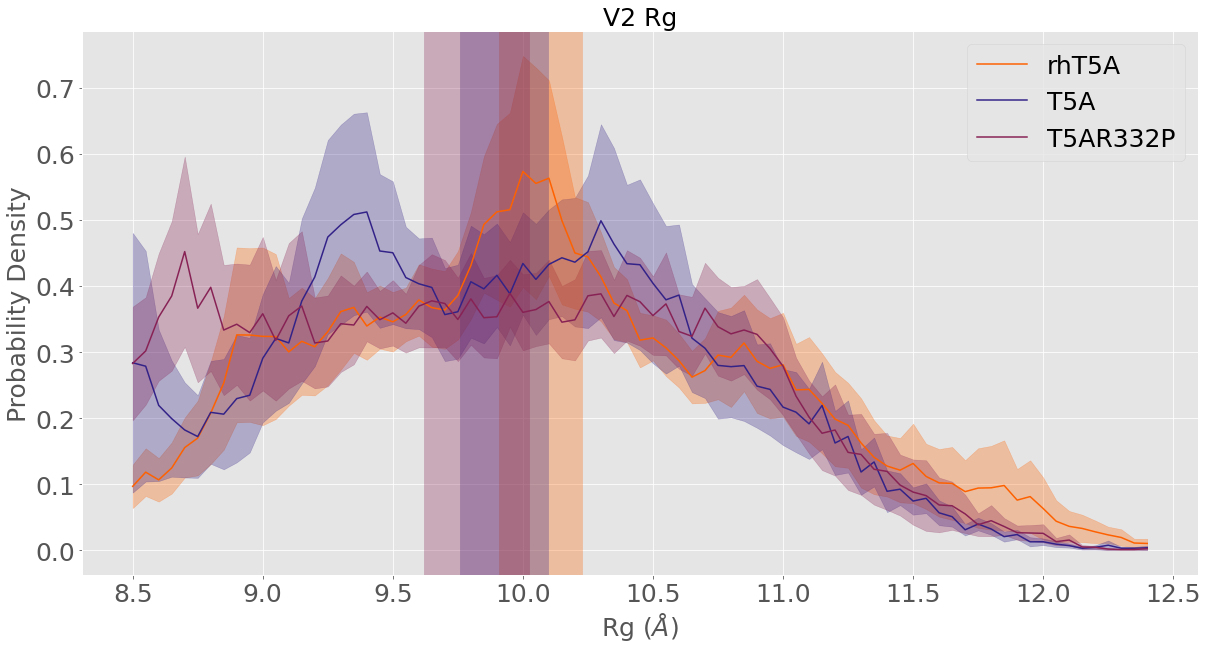

In [23]:
def getRgs(systems,datasets,selection_strings):
    allrgs=[]
    rgs=[]
    stderrs=[]
    for i in range(len(datasets)):
        subrgs=[]
        for j in range(len(datasets[i])):
            rg=[]
            for ts in systems[i][j].trajectory: 
                rg.append((systems[i][j].trajectory.time, systems[i][j].select_atoms(selection_strings[i][j]).radius_of_gyration())[1])
            subrgs.append(rg)
        allrgs.append(subrgs)

    return allrgs

allrgs = getRgs(systems,v1s,v1strings)

systemrgs=[]
for i in range(len(allrgs)):
    trjrgs=[]
    for j in range(len(allrgs[i])):
        trjrgs.append(mean(allrgs[i][j]))
    systemrgs.append(trjrgs)

    
binrange = arange(8.5,12.5,.05)
all_importantrg_histsca=[]
figure(figsize = (0,0))

for i in range(len(allrgs)):
    sub=[]
    for j in range(len(allrgs[i])):
        a=hist(allrgs[i][j][EQPOINT:],bins = binrange,density = True,alpha = 0.8,color= colourScheme[0],label = system_names[0])
        sub.append(a[0])
    all_importantrg_histsca.append(sub)
    
system_avg_importantrgsca=[]
system_sem_importantrgsca=[]

for i in range(len(all_importantrg_histsca)):
    system_avg_importantrgsca.append(mean(all_importantrg_histsca[i],axis = 0))
    system_sem_importantrgsca.append(scipy.stats.sem(all_importantrg_histsca[i],axis = 0))
    
    
    
    
trjmeans = []
for i in range(len(allrgs)):
    sub = []
    for j in range(len(allrgs[i])):
        sub.append(mean(allrgs[i][j]))
    trjmeans.append(sub)
    
actualMean= [mean(trjmeans[0]),mean(trjmeans[1]),mean(trjmeans[2])]
actualSem = [scipy.stats.sem(trjmeans[0]),scipy.stats.sem(trjmeans[1]),scipy.stats.sem(trjmeans[2])]




figure(figsize = (20,10))
plot(binrange[:-1],system_avg_importantrgsca[0],color = colourScheme[0],label = system_names[0])
plot(binrange[:-1],system_avg_importantrgsca[1],color = colourScheme[1],label = system_names[1])
plot(binrange[:-1],system_avg_importantrgsca[2],color = colourScheme[2],label = system_names[2])


fill_between(binrange[:-1], system_avg_importantrgsca[0] - system_sem_importantrgsca[0],system_avg_importantrgsca[0] + system_sem_importantrgsca[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], system_avg_importantrgsca[1] - system_sem_importantrgsca[1],system_avg_importantrgsca[1] + system_sem_importantrgsca[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], system_avg_importantrgsca[2] - system_sem_importantrgsca[2],system_avg_importantrgsca[2] + system_sem_importantrgsca[2],color = colourScheme[2],alpha = 0.3)


xlabel("Rg ($\AA$)",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
title("V2 Rg",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)

legend(fontsize = 25)

axvspan(actualMean[0] - actualSem[0],actualMean[0]+actualSem[0], color = colourScheme[0], alpha = 0.3)
axvspan(actualMean[1] - actualSem[1],actualMean[1]+actualSem[1], color = colourScheme[1], alpha = 0.3)
axvspan(actualMean[2] - actualSem[2],actualMean[2]+actualSem[2], color = colourScheme[2], alpha = 0.3)




C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:778: RuntimeWarning: invalid value encountered in double_scalars
  self._x1 = self._x0 + self._width
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:781: RuntimeWarning: invalid value encountered in double_scalars
  self._y1 = self._y0 + self._height


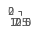

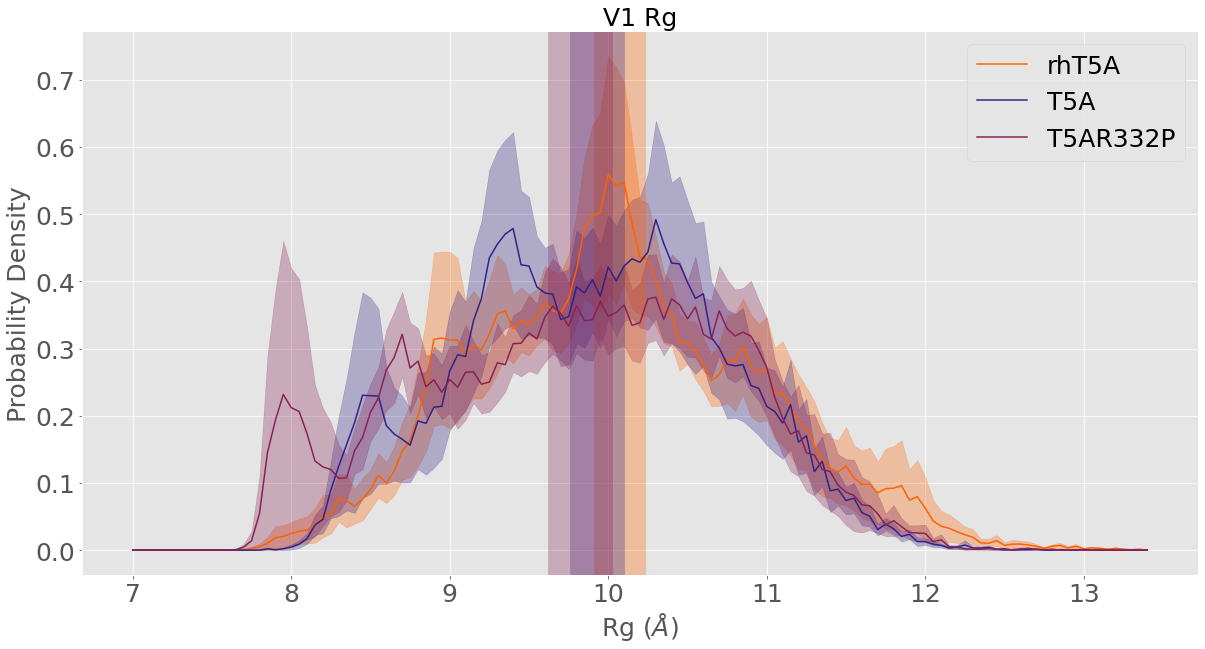

In [25]:
binrange = arange(7,13.5,.05)
all_importantrg_histsca=[]
figure(figsize = (0,0))

for i in range(len(allrgs)):
    sub=[]
    for j in range(len(allrgs[i])):
        a=hist(allrgs[i][j][EQPOINT:],bins = binrange,density = True,alpha = 0.8,color= colourScheme[0],label = system_names[0])
        sub.append(a[0])
    all_importantrg_histsca.append(sub)
    
system_avg_importantrgsca=[]
system_sem_importantrgsca=[]

for i in range(len(all_importantrg_histsca)):
    system_avg_importantrgsca.append(mean(all_importantrg_histsca[i],axis = 0))
    system_sem_importantrgsca.append(scipy.stats.sem(all_importantrg_histsca[i],axis = 0))
    
    
    
    
trjmeans = []
for i in range(len(allrgs)):
    sub = []
    for j in range(len(allrgs[i])):
        sub.append(mean(allrgs[i][j]))
    trjmeans.append(sub)
    
actualMean= [mean(trjmeans[0]),mean(trjmeans[1]),mean(trjmeans[2])]
actualSem = [scipy.stats.sem(trjmeans[0]),scipy.stats.sem(trjmeans[1]),scipy.stats.sem(trjmeans[2])]




figure(figsize = (20,10))
plot(binrange[:-1],system_avg_importantrgsca[0],color = colourScheme[0],label = system_names[0])
plot(binrange[:-1],system_avg_importantrgsca[1],color = colourScheme[1],label = system_names[1])
plot(binrange[:-1],system_avg_importantrgsca[2],color = colourScheme[2],label = system_names[2])


fill_between(binrange[:-1], system_avg_importantrgsca[0] - system_sem_importantrgsca[0],system_avg_importantrgsca[0] + system_sem_importantrgsca[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], system_avg_importantrgsca[1] - system_sem_importantrgsca[1],system_avg_importantrgsca[1] + system_sem_importantrgsca[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], system_avg_importantrgsca[2] - system_sem_importantrgsca[2],system_avg_importantrgsca[2] + system_sem_importantrgsca[2],color = colourScheme[2],alpha = 0.3)


xlabel("Rg ($\AA$)",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
title("V1 Rg",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)

legend(fontsize = 25)

axvspan(actualMean[0] - actualSem[0],actualMean[0]+actualSem[0], color = colourScheme[0], alpha = 0.3)
axvspan(actualMean[1] - actualSem[1],actualMean[1]+actualSem[1], color = colourScheme[1], alpha = 0.3)
axvspan(actualMean[2] - actualSem[2],actualMean[2]+actualSem[2], color = colourScheme[2], alpha = 0.3)

